In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os, sys
sys.path.insert(0, "/mnt/scratch/baburish/TPN-training/final/TPN_God")
import pandas as pd

import matplotlib.pyplot as plt
from lib.plotting import adjust_plot_1d

In [2]:

def GreatCircleDistance(azi_1, zen_1, azi_2, zen_2):
    """Compute the great circle distance between two events"""
    """All coordinates must be given in radians"""
    ra_1 = azi_1
    ra_2 = azi_2
    dec_1 = np.pi/2.0 - zen_1
    dec_2 = np.pi/2.0 - zen_2
    
    delta_dec = np.abs(dec_1 - dec_2)
    delta_ra = np.abs(ra_1 - ra_2)
    x = (np.sin(delta_dec / 2.))**2. + np.cos(dec_1) * \
        np.cos(dec_2) * (np.sin(delta_ra / 2.))**2.
    return 2. * np.arcsin(np.sqrt(x))

def get_gcd(df):
    """Calculate great circle distances from DataFrame"""
    # Extract columns from DataFrame
    reco_zenith = df['reco_zenith'].values
    reco_azimuth = df['reco_azimuth'].values
    true_zenith = df['muon_zenith'].values
    true_azimuth = df['muon_azimuth'].values
    spline_zenith = df['spline_mpe_zenith'].values
    spline_azimuth = df['spline_mpe_azimuth'].values
    muon_energy = df['neutrino_energy'].values
    
    # Calculate GCD
    gcd = np.rad2deg(GreatCircleDistance(true_azimuth, true_zenith, 
                                         reco_azimuth, reco_zenith))
    gcd_smpe = np.rad2deg(GreatCircleDistance(true_azimuth, true_zenith, 
                                              spline_azimuth, spline_zenith))
    
    return gcd, gcd_smpe, muon_energy

def get_quantiles(dpsi, energy, e_bins):
    """Calculate quantiles in energy bins"""
    lower, med, upper = [], [], []
    for el, eh in zip(e_bins[:-1], e_bins[1:]):
        idx = np.logical_and(energy >= el, energy < eh)
        if np.sum(idx) == 0:  # Skip empty bins
            continue
        l, m, u = np.percentile(dpsi[idx], [20, 50, 80])
        lower.append(l)
        med.append(m)
        upper.append(u)
    return lower, med, upper

def get_resolution(df):
    """Calculate resolution from DataFrame"""
    gcd, gcd_smpe, muon_energy = get_gcd(df)
    
    # Print energy statistics
    print("Muon energy range:")
    print(f"  Min: {np.min(muon_energy):.2e}")
    print(f"  Max: {np.max(muon_energy):.2e}")
    print(f"  Log10 range: {np.log10(np.min(muon_energy)):.2f} to {np.log10(np.max(muon_energy)):.2f}")
    
    # Create energy bins based on actual data range
    e_log = np.log10(muon_energy)
    e_min = np.floor(np.min(e_log) * 10) / 10  # Round down
    e_max = np.ceil(np.max(e_log) * 10) / 10   # Round up
    e_nu_range = [e_min, e_max]
    e_nu_bins = np.linspace(*e_nu_range, 11)
    
    print(f"\nEnergy bins: {e_nu_range}")
    print(f"Number of events in range: {np.sum((e_log >= e_nu_range[0]) & (e_log < e_nu_range[1]))}")
    
    # Calculate quantiles
    centers = lambda x: 0.5 * (x[:-1] + x[1:])
    e_nu_centers = centers(e_nu_bins)
    
    lower, med, upper = get_quantiles(gcd, e_log, e_nu_bins)
    lower2, med2, upper2 = get_quantiles(gcd_smpe, e_log, e_nu_bins)
    
    return (lower, med, upper), (lower2, med2, upper2), e_nu_centers

# Load and analyze

In [5]:

print("Loading results...")
df1 = pd.read_csv('/mnt/scratch/baburish/TPN-training/final/TPN_God/results/result_22644_0_to_1000.csv')
df2 = pd.read_csv('/mnt/scratch/baburish/TPN-training/final/TPN_God/results/result_22644_1000_to_2000.csv')
df3 = pd.read_csv('/mnt/scratch/baburish/TPN-training/final/TPN_God/results/result_22645_1000_to_2000.csv')
df4 = pd.read_csv('/mnt/scratch/baburish/TPN-training/final/TPN_God/results/result_22645_0_to_1000.csv')
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Calculate resolution
r_seed_smpe, r_smpe, xvals = get_resolution(df)

print(f"\nResolution calculated:")
print(f"  Reconstruction: {len(r_seed_smpe[1])} bins")
print(f"  SplineMPE: {len(r_smpe[1])} bins")

Loading results...

DataFrame shape: (118898, 27)
Columns: ['neutrino_energy', 'q_tot', 'muon_zenith', 'muon_azimuth', 'muon_time', 'muon_pos_x', 'muon_pos_y', 'muon_pos_z', 'spline_mpe_zenith', 'spline_mpe_azimuth', 'spline_mpe_time', 'spline_mpe_pos_x', 'spline_mpe_pos_y', 'spline_mpe_pos_z', 'linefit_zenith', 'linefit_azimuth', 'linefit_time', 'linefit_pos_x', 'linefit_pos_y', 'linefit_pos_z', 'reco_logl', 'reco_zenith', 'reco_azimuth', 'reco_pos_x', 'reco_pos_y', 'reco_pos_z', 'reco_time']
Muon energy range:
  Min: 1.00e+04
  Max: 1.00e+08
  Log10 range: 4.00 to 8.00

Energy bins: [4.0, 8.0]
Number of events in range: 118898

Resolution calculated:
  Reconstruction: 10 bins
  SplineMPE: 10 bins


In [6]:
def adjust_plot_1d(fig, ax, plot_args=None):
    if not plot_args:
        plot_args = {}

    for axis in ['top','bottom','left','right']:
          ax.spines[axis].set_linewidth(1.5)
          ax.spines[axis].set_color('0.0')

    y_scale_in_log = plot_args.get('y_axis_in_log', False)
    if(y_scale_in_log):
        ax.set_yscale('log')

    ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=18)
    ax.yaxis.set_ticks_position('both')
    ax.set_ylabel(plot_args.get('ylabel', 'pdf'), fontsize=20)
    ax.set_xlabel(plot_args.get('xlabel', 'var 1'), fontsize=20)
    ax.set_ylim(plot_args.get('ylim', [0, 1]))
    ax.set_xlim(plot_args.get('xlim', [0, 1]))
    ax.legend()


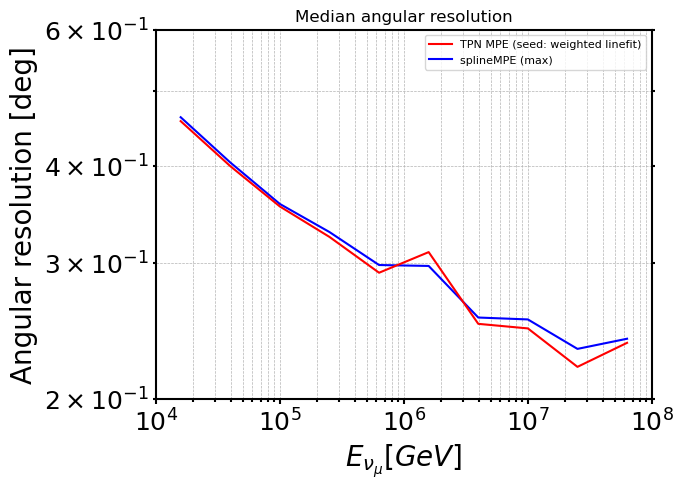

In [12]:
fig, ax = plt.subplots()
plot_args = {'xlabel':'$E_{\\nu_{\\mu}} [GeV]$', 
                 'ylabel':'Angular resolution [deg]', 
                 'xlim':[10**4.0, 10**8.0], 
                 'ylim':[0.2, 0.6]}

ax.plot(10**xvals, r_seed_smpe[1], color='red', label='TPN MPE (seed: weighted linefit)', linestyle='solid', zorder=17)
# ax.plot(10**xvals, r_seed_truth[1], color='purple', label='TPN MPE (seed: truth)', linestyle='dashed', zorder=17)
ax.plot(10**xvals, r_smpe[1], color='blue', label='splineMPE (max)')

adjust_plot_1d(fig, ax, plot_args=plot_args)
# plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='0.7')
plt.xscale('log')
plt.yscale('log')
# plt.title('Median angular resolution (3ns convolution), Spice 3.2.1')
plt.title('Median angular resolution')
# ax.set_yticks([0.2*i for i in range(9)][1:-2])
plt.legend(fontsize=8, loc='upper right')
plt.show()

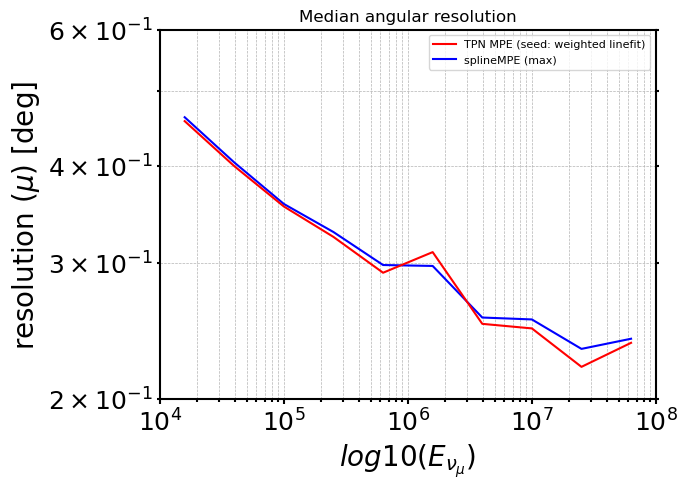

In [9]:
fig, ax = plt.subplots()

plot_args = {
    'xlabel': '$log10(E_{\\nu_{\\mu}})$',
    'ylabel': 'resolution ($\mu$) [deg]',
    'xlim': [10**4.0, 10**8.0],
     'ylim':[0.2, 0.6]
}

x = 10**xvals

# TPN MPE
ax.plot(x, r_seed_smpe[1], color='red', label='TPN MPE (seed: weighted linefit)', linestyle='solid', zorder=17)
# ax.plot(x, r_seed_smpe[0], color='red', linestyle='dotted', zorder=17)
# ax.plot(x, r_seed_smpe[2], color='red', linestyle='dotted', zorder=17)

# SplineMPE
ax.plot(x, r_smpe[1], color='blue', label='splineMPE (max)')
# ax.plot(x, r_smpe[0], color='blue', linestyle='dotted')
# ax.plot(x, r_smpe[2], color='blue', linestyle='dotted')

adjust_plot_1d(fig, ax, plot_args=plot_args)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='0.7')
plt.xscale('log')
plt.yscale('log')
plt.title('Median angular resolution')
plt.legend(fontsize=8, loc='upper right')
plt.show()

/tmp/ipykernel_2589524/2435948742.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


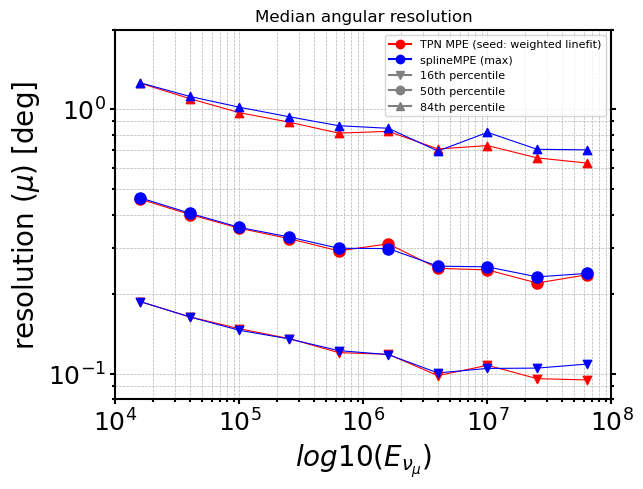

In [ ]:
fig, ax = plt.subplots()

plot_args = {
    'xlabel': '$log10(E_{\\nu_{\\mu}})$',
    'ylabel': 'resolution ($\mu$) [deg]',
    'xlim': [10**4.0, 10**8.0],
    'ylim': [0.08, 2]
}

x = 10**xvals

# TPN MPE - lines connecting scatter points
for q, marker, ms in zip([r_seed_smpe[0], r_seed_smpe[1], r_seed_smpe[2]], 
                          ['v', 'o', '^'], [6, 8, 6]):
    ax.plot(x, q, color='red', linestyle='solid', linewidth=0.8, zorder=16)
    ax.scatter(x, q, color='red', marker=marker, s=ms**2, zorder=17)

# SplineMPE - lines connecting scatter points
for q, marker, ms in zip([r_smpe[0], r_smpe[1], r_smpe[2]], 
                          ['v', 'o', '^'], [6, 8, 6]):
    ax.plot(x, q, color='blue', linestyle='solid', linewidth=0.8, zorder=16)
    ax.scatter(x, q, color='blue', marker=marker, s=ms**2, zorder=17)

# Custom legend entries
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red',  marker='o', linestyle='solid', label='TPN MPE (seed: weighted linefit)'),
    Line2D([0], [0], color='blue', marker='o', linestyle='solid', label='splineMPE (max)'),
    Line2D([0], [0], color='gray', marker='v', linestyle='solid', label='16th percentile'),
    Line2D([0], [0], color='gray', marker='o', linestyle='solid', label='50th percentile'),
    Line2D([0], [0], color='gray', marker='^', linestyle='solid', label='84th percentile'),
]

adjust_plot_1d(fig, ax, plot_args=plot_args)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='0.7')
plt.xscale('log')
plt.yscale('log')
plt.title('Median angular resolution')
ax.legend(handles=legend_elements, fontsize=8, loc='upper right')
plt.show()

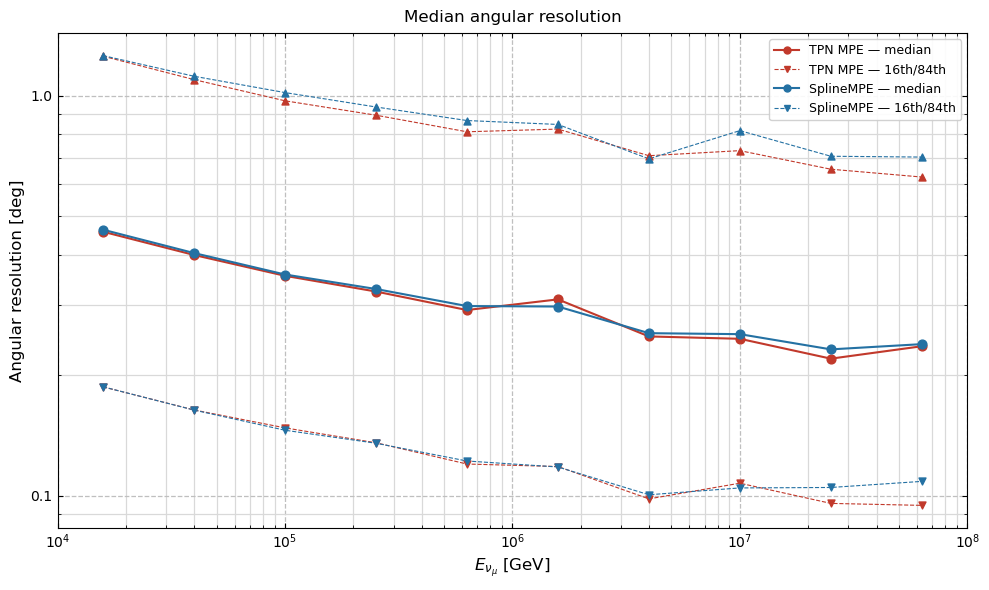

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

x = 10**xvals

# --- TPN MPE ---
ax.plot(x, r_seed_smpe[1], color='#C1392B', lw=1.5, zorder=4)
ax.scatter(x, r_seed_smpe[1], color='#C1392B', marker='o', s=40, zorder=5, label='TPN MPE — median')
ax.plot(x, r_seed_smpe[0], color='#C1392B', lw=0.8, ls='--', zorder=3)
ax.scatter(x, r_seed_smpe[0], color='#C1392B', marker='v', s=25, zorder=4, label='TPN MPE — 16th/84th')
ax.plot(x, r_seed_smpe[2], color='#C1392B', lw=0.8, ls='--', zorder=3)
ax.scatter(x, r_seed_smpe[2], color='#C1392B', marker='^', s=25, zorder=4)

# --- SplineMPE ---
ax.plot(x, r_smpe[1], color='#2471A3', lw=1.5, zorder=4)
ax.scatter(x, r_smpe[1], color='#2471A3', marker='o', s=40, zorder=5, label='SplineMPE — median')
ax.plot(x, r_smpe[0], color='#2471A3', lw=0.8, ls='--', zorder=3)
ax.scatter(x, r_smpe[0], color='#2471A3', marker='v', s=25, zorder=4, label='SplineMPE — 16th/84th')
ax.plot(x, r_smpe[2], color='#2471A3', lw=0.8, ls='--', zorder=3)
ax.scatter(x, r_smpe[2], color='#2471A3', marker='^', s=25, zorder=4)

# --- Axes ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e4, 1e8)
ax.set_xlabel(r'$E_{\nu_\mu}$ [GeV]', fontsize=12)
ax.set_ylabel(r'Angular resolution [deg]', fontsize=12)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=10)

# --- Grid ---
ax.grid(True, which='major', ls='--', lw=0.9, color='0.75')
ax.grid(True, which='minor', ls='-', lw=0.9, color='0.85')

# --- Legend ---
# Deduplicate: markers for 16th/84th share one entry per colour
from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color='#C1392B', lw=1.5, marker='o', ms=5, label='TPN MPE — median'),
    Line2D([0],[0], color='#C1392B', lw=0.8, ls='--', marker='v', ms=4, label='TPN MPE — 16th/84th'),
    Line2D([0],[0], color='#2471A3', lw=1.5, marker='o', ms=5, label='SplineMPE — median'),
    Line2D([0],[0], color='#2471A3', lw=0.8, ls='--', marker='v', ms=4, label='SplineMPE — 16th/84th'),
]
ax.legend(handles=handles, fontsize=9, framealpha=0.9,
          edgecolor='0.8', loc='upper right')

ax.set_title('Median angular resolution', fontsize=12, pad=8)
fig.tight_layout()
# plt.savefig('angular_resolution.pdf', dpi=300, bbox_inches='tight')
plt.show()

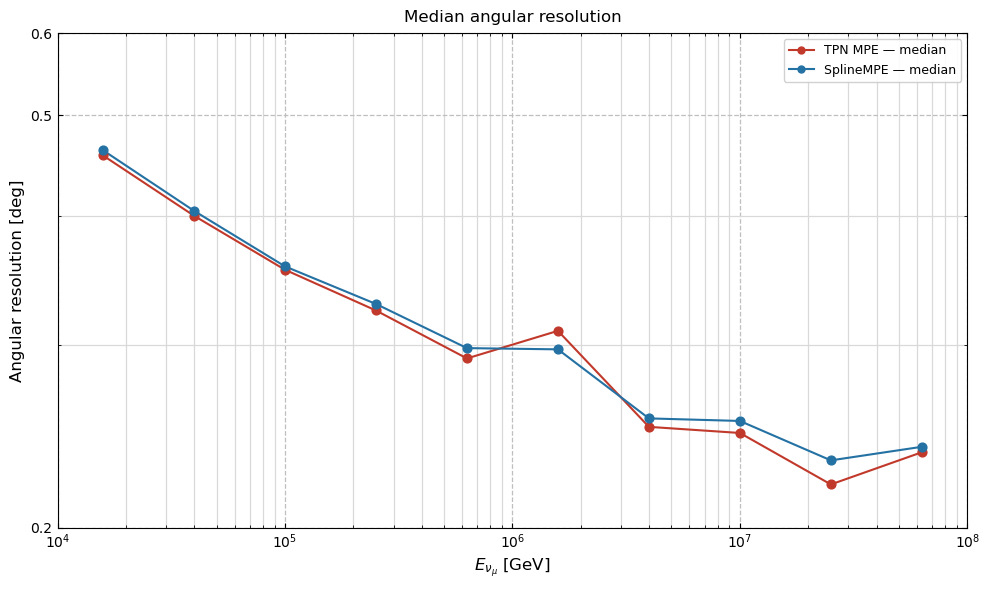

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

x = 10**xvals

# --- TPN MPE ---
ax.plot(x, r_seed_smpe[1], color='#C1392B', lw=1.5, zorder=4)
ax.scatter(x, r_seed_smpe[1], color='#C1392B', marker='o', s=40, zorder=5, label='TPN MPE — median')
# ax.plot(x, r_seed_smpe[0], color='#C1392B', lw=0.8, ls='--', zorder=3)
# ax.scatter(x, r_seed_smpe[0], color='#C1392B', marker='v', s=25, zorder=4, label='TPN MPE — 16th/84th')
# ax.plot(x, r_seed_smpe[2], color='#C1392B', lw=0.8, ls='--', zorder=3)
# ax.scatter(x, r_seed_smpe[2], color='#C1392B', marker='^', s=25, zorder=4)

# --- SplineMPE ---
ax.plot(x, r_smpe[1], color='#2471A3', lw=1.5, zorder=4)
ax.scatter(x, r_smpe[1], color='#2471A3', marker='o', s=40, zorder=5, label='SplineMPE — median')
# ax.plot(x, r_smpe[0], color='#2471A3', lw=0.8, ls='--', zorder=3)
# ax.scatter(x, r_smpe[0], color='#2471A3', marker='v', s=25, zorder=4, label='SplineMPE — 16th/84th')
# ax.plot(x, r_smpe[2], color='#2471A3', lw=0.8, ls='--', zorder=3)
# ax.scatter(x, r_smpe[2], color='#2471A3', marker='^', s=25, zorder=4)

# --- Axes ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e4, 1e8)
ax.set_xlabel(r'$E_{\nu_\mu}$ [GeV]', fontsize=12)
ax.set_ylabel(r'Angular resolution [deg]', fontsize=12)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=10)

# --- Grid ---
ax.grid(True, which='major', ls='--', lw=0.9, color='0.75')
ax.grid(True, which='minor', ls='-', lw=0.9, color='0.85')

# --- Legend ---
# Deduplicate: markers for 16th/84th share one entry per colour
from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color='#C1392B', lw=1.5, marker='o', ms=5, label='TPN MPE — median'),
    # Line2D([0],[0], color='#C1392B', lw=0.8, ls='--', marker='v', ms=4, label='TPN MPE — 16th/84th'),
    Line2D([0],[0], color='#2471A3', lw=1.5, marker='o', ms=5, label='SplineMPE — median'),
    # Line2D([0],[0], color='#2471A3', lw=0.8, ls='--', marker='v', ms=4, label='SplineMPE — 16th/84th'),
]
ax.legend(handles=handles, fontsize=9, framealpha=0.9,
          edgecolor='0.8', loc='upper right')

ax.set_title('Median angular resolution', fontsize=12, pad=8)
ax.set_yticks([ 0.2, 0.5, 0.6,])
fig.tight_layout()
# plt.savefig('angular_resolution.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
gcd, gcd_smpe, _ = get_gcd(df)

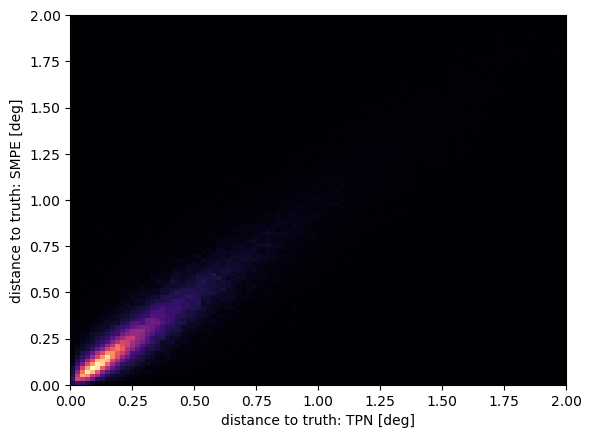

In [ ]:
bins = np.linspace(0.0, 2.0, 100)
plt.hist2d(gcd, gcd_smpe, bins=bins, cmap='magma', )
plt.xlabel("distance to truth: TPN [deg]")
plt.ylabel("distance to truth: SMPE [deg]")
plt.show()

Text(0, 0.5, 'distance to truth: SMPE [deg]')

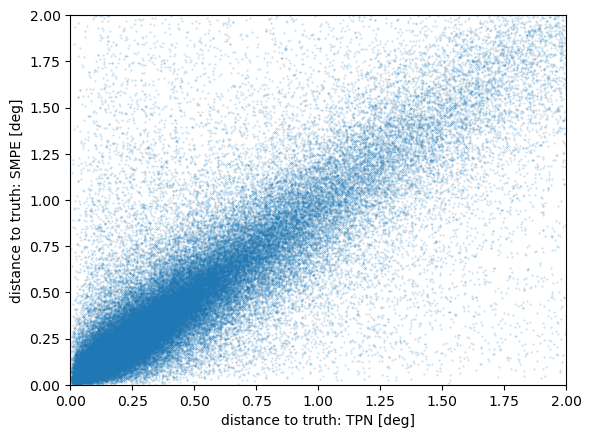

In [ ]:
plt.scatter(gcd, gcd_smpe, s=0.1, alpha=0.4)
plt.xlim(0.0, 2.0)
plt.ylim(0.0, 2.0)
plt.xlabel("distance to truth: TPN [deg]")
plt.ylabel("distance to truth: SMPE [deg]")

In [34]:
print(f"Columns: {df1.columns.tolist()}")

Columns: ['neutrino_energy', 'q_tot', 'muon_zenith', 'muon_azimuth', 'muon_time', 'muon_pos_x', 'muon_pos_y', 'muon_pos_z', 'spline_mpe_zenith', 'spline_mpe_azimuth', 'spline_mpe_time', 'spline_mpe_pos_x', 'spline_mpe_pos_y', 'spline_mpe_pos_z', 'linefit_zenith', 'linefit_azimuth', 'linefit_time', 'linefit_pos_x', 'linefit_pos_y', 'linefit_pos_z', 'reco_logl', 'reco_zenith', 'reco_azimuth', 'reco_pos_x', 'reco_pos_y', 'reco_pos_z', 'reco_time']


In [36]:
median_a = df1["neutrino_energy"].median()/1e3
print(median_a)

10467.684473531745


In [37]:
median_a = df2["neutrino_energy"].median()/1e3
print(median_a)

10467.684473531745


In [38]:
median_a = df3["neutrino_energy"].median()/1e3
print(median_a)

37.64707100411961


In [39]:
median_a = df4["neutrino_energy"].median()/1e3
print(median_a)

37.9426061963393
